In [1]:
# Imports
import pandas as pd
import numpy as np
import os
import optuna
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

c:\Users\khiew\anaconda3\envs\LSTM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Check for GPU
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.set_visible_devices(physical_devices[0], 'GPU')
    print(f"Using GPU: {physical_devices[0].name}")
else:
    print("No GPUs found, using CPU instead.")

# Load dataset
df = pd.read_csv("C:\\Users\\khiew\\Downloads\\archive (3)\\train.csv")
df = df[['Question', 'Answer']]
df = df.drop_duplicates()

Using GPU: /physical_device:GPU:0


In [4]:
# Split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Tokenizer
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['Question'].tolist() + df['Answer'].tolist())
vocab_size = len(tokenizer.word_index) + 1

# Add <sos> and <eos>
train_df['Answer_in'] = '<sos> ' + train_df['Answer']
val_df['Answer_in'] = '<sos> ' + val_df['Answer']
train_df['Answer_out'] = train_df['Answer'] + ' <eos>'
val_df['Answer_out'] = val_df['Answer'] + ' <eos>'

# Tokenize
X_encoder_train = tokenizer.texts_to_sequences(train_df['Question'])
X_encoder_val = tokenizer.texts_to_sequences(val_df['Question'])
X_decoder_train = tokenizer.texts_to_sequences(train_df['Answer_in'])
X_decoder_val = tokenizer.texts_to_sequences(val_df['Answer_in'])
y_decoder_train = tokenizer.texts_to_sequences(train_df['Answer_out'])
y_decoder_val = tokenizer.texts_to_sequences(val_df['Answer_out'])

In [5]:
# Pad
max_len = 175
X_encoder_train = pad_sequences(X_encoder_train, maxlen=max_len, padding='post', truncating='post')
X_encoder_val = pad_sequences(X_encoder_val, maxlen=max_len, padding='post', truncating='post')
X_decoder_train = pad_sequences(X_decoder_train, maxlen=max_len, padding='post', truncating='post')
X_decoder_val = pad_sequences(X_decoder_val, maxlen=max_len, padding='post', truncating='post')
y_decoder_train = pad_sequences(y_decoder_train, maxlen=max_len, padding='post', truncating='post')
y_decoder_val = pad_sequences(y_decoder_val, maxlen=max_len, padding='post', truncating='post')

# Fix output shape
y_decoder_train = np.expand_dims(y_decoder_train, -1)
y_decoder_val = np.expand_dims(y_decoder_val, -1)

In [6]:
def build_seq2seq_model(trial_or_params):
    if isinstance(trial_or_params, dict):
        params = trial_or_params
        embedding_dim = params['embedding_dim']
        lstm_units = params['lstm_units']
        dropout_rate = params['dropout_rate']
        optimizer_name = params['optimizer']
    else:
        embedding_dim = trial_or_params.suggest_int('embedding_dim', 32, 128)
        lstm_units = trial_or_params.suggest_int('lstm_units', 32, 128)
        dropout_rate = trial_or_params.suggest_float('dropout_rate', 0.1, 0.5)
        optimizer_name = trial_or_params.suggest_categorical('optimizer', ['adam', 'rmsprop'])

    encoder_inputs = Input(shape=(max_len,))
    enc_emb = Embedding(vocab_size, embedding_dim, mask_zero=True)(encoder_inputs)
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, dropout=dropout_rate)
    encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

    decoder_inputs = Input(shape=(max_len,))
    dec_emb = Embedding(vocab_size, embedding_dim, mask_zero=True)(decoder_inputs)
    decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, dropout=dropout_rate)
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

    attention = Attention(use_scale=True)([decoder_outputs, encoder_outputs])
    context_vector = Concatenate(axis=-1)([decoder_outputs, attention])
    decoder_dense = Dense(vocab_size, activation='softmax')
    output = decoder_dense(context_vector)

    model = Model([encoder_inputs, decoder_inputs], output)

    optimizer = Adam() if optimizer_name == 'adam' else RMSprop()
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [7]:
# Objective function
def objective(trial):
    model = build_seq2seq_model(trial)
    history = model.fit(
        [X_encoder_train, X_decoder_train],
        y_decoder_train,
        batch_size=32,
        epochs=20,
        validation_data=([X_encoder_val, X_decoder_val], y_decoder_val),
        verbose=0
    )
    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [10]:
# Optimize with Optuna
study = optuna.create_study(
    direction='maximize',
    study_name="LSTM_Batch32_Token175_Epochs20LargeRangewithAttTesting",
    storage=r"sqlite:///C:/Users/khiew/Downloads/LSTM_Chatbot.db",
    load_if_exists=True
)
study.optimize(objective, n_trials=5)

# Print best results
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-29 19:55:03,087] A new study created in RDB with name: LSTM_Batch32_Token175_Epochs20LargeRangewithAttTesting
[I 2025-04-29 20:09:35,584] Trial 0 finished with value: 0.38921043276786804 and parameters: {'dropout_rate': 0.13580573927286443, 'embedding_dim': 47, 'lstm_units': 38, 'optimizer': 'adam'}. Best is trial 0 with value: 0.38921043276786804.
[I 2025-04-29 20:24:25,356] Trial 1 finished with value: 0.42296022176742554 and parameters: {'dropout_rate': 0.18670183164740145, 'embedding_dim': 92, 'lstm_units': 57, 'optimizer': 'adam'}. Best is trial 1 with value: 0.42296022176742554.
[I 2025-04-29 20:40:53,518] Trial 2 finished with value: 0.43239930272102356 and parameters: {'dropout_rate': 0.4254730620375142, 'embedding_dim': 100, 'lstm_units': 102, 'optimizer': 'adam'}. Best is trial 2 with value: 0.43239930272102356.
[I 2025-04-29 20:57:21,246] Trial 3 finished with value: 0.43217480182647705 and parameters: {'dropout_rate': 0.15379666838235512, 'embedding_dim': 55, 'ls


Best Trial:
FrozenTrial(number=2, state=TrialState.COMPLETE, values=[0.43239930272102356], datetime_start=datetime.datetime(2025, 4, 29, 20, 24, 25, 356650), datetime_complete=datetime.datetime(2025, 4, 29, 20, 40, 53, 497836), params={'dropout_rate': 0.4254730620375142, 'embedding_dim': 100, 'lstm_units': 102, 'optimizer': 'adam'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'embedding_dim': IntDistribution(high=128, log=False, low=32, step=1), 'lstm_units': IntDistribution(high=128, log=False, low=32, step=1), 'optimizer': CategoricalDistribution(choices=('adam', 'rmsprop'))}, trial_id=82, value=None)
Best Hyperparameters:
{'dropout_rate': 0.4254730620375142, 'embedding_dim': 100, 'lstm_units': 102, 'optimizer': 'adam'}


In [8]:
# Optimize with Optuna
study = optuna.create_study(
    direction='maximize',
    study_name="LSTM_Batch32_Token175_Epochs20LargeRangewithAttTesting",
    storage=r"sqlite:///C:/Users/khiew/Downloads/LSTM_Chatbot.db",
    load_if_exists=True
)
study.optimize(objective, n_trials=1)

# Print best results
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-30 11:03:30,005] Using an existing study with name 'LSTM_Batch32_Token175_Epochs20LargeRangewithAttTesting' instead of creating a new one.
[I 2025-04-30 11:19:50,465] Trial 7 finished with value: 0.44534656405448914 and parameters: {'dropout_rate': 0.15907123229704753, 'embedding_dim': 88, 'lstm_units': 105, 'optimizer': 'rmsprop'}. Best is trial 7 with value: 0.44534656405448914.



Best Trial:
FrozenTrial(number=7, state=TrialState.COMPLETE, values=[0.44534656405448914], datetime_start=datetime.datetime(2025, 4, 30, 11, 3, 30, 129175), datetime_complete=datetime.datetime(2025, 4, 30, 11, 19, 50, 453777), params={'dropout_rate': 0.15907123229704753, 'embedding_dim': 88, 'lstm_units': 105, 'optimizer': 'rmsprop'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'embedding_dim': IntDistribution(high=128, log=False, low=32, step=1), 'lstm_units': IntDistribution(high=128, log=False, low=32, step=1), 'optimizer': CategoricalDistribution(choices=('adam', 'rmsprop'))}, trial_id=87, value=None)
Best Hyperparameters:
{'dropout_rate': 0.15907123229704753, 'embedding_dim': 88, 'lstm_units': 105, 'optimizer': 'rmsprop'}


In [12]:
# Rebuild best model
best_params = study.best_trial.params
class BestTrial:
    def __init__(self, params): self.params = params
model = build_seq2seq_model(best_params)
history = model.fit(
    [X_encoder_train, X_decoder_train],
    y_decoder_train,
    batch_size=32,
    epochs=20,
    validation_data=([X_encoder_val, X_decoder_val], y_decoder_val),
    verbose=1
)

Epoch 1/20
409/409 [==============================] - 280s 645ms/step - loss: 4.5842 - accuracy: 0.0780 - val_loss: 4.2151 - val_accuracy: 0.1208
Epoch 2/20
409/409 [==============================] - 302s 740ms/step - loss: 3.8348 - accuracy: 0.2015 - val_loss: 3.5995 - val_accuracy: 0.2740
Epoch 3/20
409/409 [==============================] - 342s 838ms/step - loss: 3.3636 - accuracy: 0.3004 - val_loss: 3.2574 - val_accuracy: 0.3251
Epoch 4/20
409/409 [==============================] - 418s 1s/step - loss: 3.1080 - accuracy: 0.3378 - val_loss: 3.0759 - val_accuracy: 0.3506
Epoch 5/20
409/409 [==============================] - 459s 1s/step - loss: 2.9561 - accuracy: 0.3593 - val_loss: 2.9621 - val_accuracy: 0.3670
Epoch 6/20
409/409 [==============================] - 463s 1s/step - loss: 2.8513 - accuracy: 0.3744 - val_loss: 2.8784 - val_accuracy: 0.3798
Epoch 7/20
409/409 [==============================] - 436s 1s/step - loss: 2.7696 - accuracy: 0.3867 - val_loss: 2.8144 - val_accurac

In [10]:
def decode_sequence(input_seq, model, tokenizer, max_len):
    encoder_input = pad_sequences(tokenizer.texts_to_sequences([input_seq]), maxlen=max_len, padding='post')
    decoder_input = tokenizer.texts_to_sequences(['<sos>'])
    decoder_input = pad_sequences([decoder_input], maxlen=max_len, padding='post')

    for i in range(1, max_len):
        output_tokens = model.predict([encoder_input, decoder_input], verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, i-1, :])
        sampled_word = tokenizer.index_word.get(sampled_token_index, '')
        if sampled_word == '<eos>':
            break
        decoder_input[0, i] = sampled_token_index

    # Ensure that decoder_input is flattened and get the word from index
    decoded_sequence = ' '.join([tokenizer.index_word.get(idx, '') 
                                 for idx in decoder_input[0].flatten() if idx != 0])  # .flatten() here
    return decoded_sequence.replace('<sos>', '').strip()


In [11]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu

# Initialize the ROUGE scorer
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'])

bleu_scores = []
rouge_scores = []

for i in range(50):
    question = val_df.iloc[i]['Question']
    actual = val_df.iloc[i]['Answer']
    predicted = decode_sequence(question, model, tokenizer, max_len)

    # BLEU score calculation
    bleu = sentence_bleu([actual.split()], predicted.split(), weights=(0.5, 0.5))
    bleu_scores.append(bleu)

    # ROUGE-L score calculation
    scores = rouge.score(actual, predicted)  # Get all ROUGE scores
    rouge_l_score = scores['rougeL'].fmeasure  # Get the ROUGE-L f-measure score
    rouge_scores.append(rouge_l_score)

print(f"\nBLEU score (avg over 50 samples): {np.mean(bleu_scores):.4f}")
print(f"ROUGE-L score (avg): {np.mean(rouge_scores):.4f}")


c:\Users\khiew\anaconda3\envs\LSTM\lib\site-packages\nltk\translate\bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)



BLEU score (avg over 50 samples): 0.0762
ROUGE-L score (avg): 0.1791


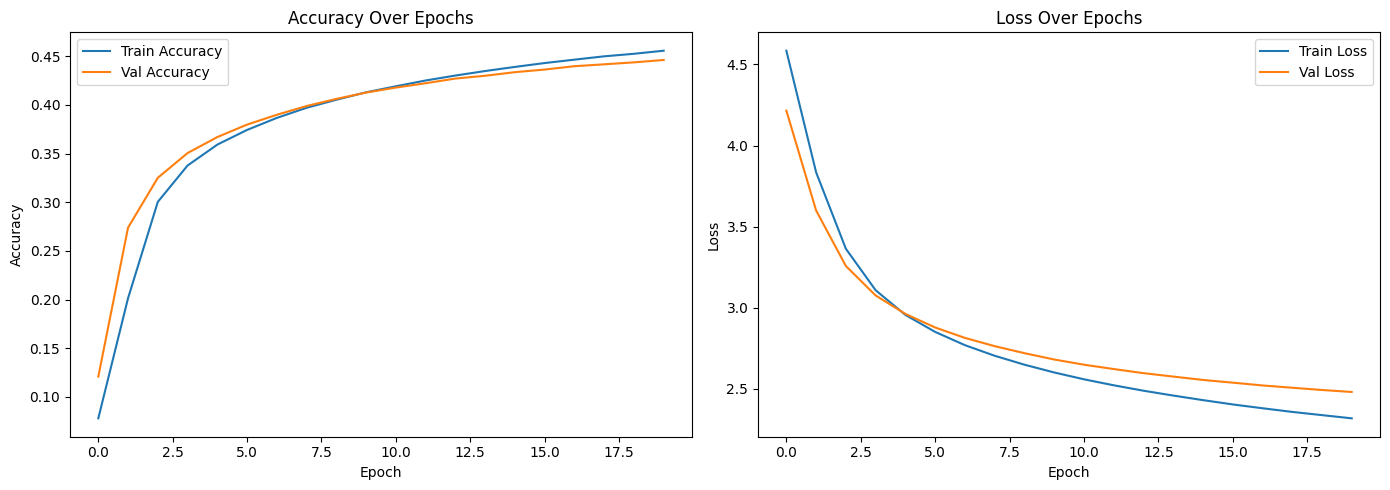

In [13]:
# Plot training history
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()